### Controlled predictor analysis — Condition & Vegetation response

For each of the nine predictors
(berm length, slope, landform, soil texture, B-horizon presence,
flow accumulation, clay content, silt content, sand content), this notebook asks:

> **Does the predictor remain significant after controlling for
> the other eight?**

Methods per predictor:

1. **Univariate association (chi-square / Fisher exact / univariate logistic)**
   These tests assess whether a single predictor is related to the outcome *without adjusting for anything else*. Chi-square and Fisher exact tests treat both the predictor and outcome as categorical — Fisher exact is the small-sample alternative when expected cell counts drop below about 5. Univariate logistic regression serves the same purpose but can handle continuous predictors (like flow accumulation or slope) without binning them, and it yields an odds ratio that quantifies the direction and magnitude of the effect. This step establishes a baseline: does the predictor matter at all in isolation?

2. **Multivariate logistic regression — focal predictor coefficient**
   All nine predictors are entered simultaneously into a single logistic regression model. The coefficient (and corresponding odds ratio) for each predictor now reflects its association with the outcome *after holding the other eight constant*. A predictor whose coefficient is significant here has explanatory power that is not redundant with the other variables. Comparing univariate and multivariate coefficients reveals confounding: if a predictor is significant univariately but not in the full model, its apparent effect was being driven by correlated covariates.

3. **Likelihood-ratio test (full model vs model without focal predictor)**
   For each focal predictor we fit a *reduced* model that drops only that predictor's term(s) and compare it to the full model using a likelihood-ratio χ² test. The test statistic is $LR = -2(\ell_{\text{reduced}} - \ell_{\text{full}})$, which follows a χ² distribution with degrees of freedom equal to the number of coefficients removed (1 for a continuous or binary predictor; more for multi-level categoricals). A significant LRT means the full model fits meaningfully better, so the focal predictor contributes unique information beyond the other eight. We also report ΔAIC = AIC(reduced) − AIC(full); values above +2 indicate a meaningful independent contribution.

4. **Random-forest permutation importance**
   As a model-agnostic robustness check, we fit a 500-tree random forest (max depth 5, balanced class weights) with all predictors and then measure each predictor's importance by randomly permuting its values and recording the drop in accuracy (averaged over 30 repeats). Predictors whose permutation causes a large accuracy drop are important to the model regardless of linearity assumptions or collinearity structure. Five-fold stratified cross-validated AUC provides an overall measure of the model's discriminative ability.

Both outcomes are analysed:
- **Berm condition** (Intact vs Degraded)
- **Vegetation response** (Response vs No response)


In [2]:
import sys as _sys
_sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import fisher_exact, chi2_contingency, chi2 as chi2_dist
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

from constants import LBL_EFFECTIVE, LBL_INEFFECTIVE
from analysis import PRETTY_LABELS


In [3]:
data = pd.read_csv('../data/merged.csv')

# Binary outcome columns
data['_intact_01'] = data['Intact'].astype(int)
data['_effective_01'] = (data['Effective'] == LBL_EFFECTIVE).astype(int)

# Binary encoding for categorical predictors used in the model
data['_has_B'] = (data['Soil_Development'] == 'B horizon').astype(int)

print(f"Loaded {len(data):,} berms")
print(f"  Intact rate:     {data['_intact_01'].mean():.1%}")
print(f"  Effective rate:  {data['_effective_01'].mean():.1%}")


Loaded 775 berms
  Intact rate:     59.1%
  Effective rate:  47.5%


## Methodology

### Motivation

The grouped-bar figures (Figs 4–5) test each predictor's univariate association with berm condition and vegetation response — Fisher exact tests for two-category comparisons (e.g., short vs long berms) and chi-square tests for multi-category predictors (e.g., landform, soil texture). However, univariate tests cannot distinguish direct effects from confounded effects. For example, landform covaries with slope, soil texture, and flow accumulation — so a significant univariate landform effect may really reflect slope differences between landforms.

To isolate each predictor's *independent* contribution we use a *drop-one likelihood-ratio test (LRT)* framework:

1. Fit a *full logistic regression* with all nine predictors entering simultaneously.
2. For each focal predictor, fit a *reduced model* that drops only that predictor.
3. Compare the two models with a likelihood-ratio χ² test (df = number of coefficients removed).

Each model has a log-likelihood — a measure of how probable the observed data are under that model. The LRT statistic is $LR = -2(\ell_{\text{reduced}} - \ell_{\text{full}})$, which is always ≥ 0 because adding parameters can only improve or maintain fit. Under the null hypothesis that the removed predictor has no effect, $LR$ follows a χ² distribution with degrees of freedom equal to the number of coefficients dropped (1 for a continuous or binary predictor, 2 for landform, 7 for soil texture). A large $LR$ (small p-value) means the full model fits meaningfully better, so the focal predictor contributes information beyond what the other predictors already explain.

This directly answers: *does including predictor X improve the model beyond what the other eight predictors already explain?*

### Full model specification

$$\text{logit}\bigl(P(Y=1)\bigr) = \beta_0 + \beta_1\,\text{Shape\_Leng} + \beta_2\,\text{slope\_200} + \beta_3\,\text{FA\_30\_max} + \beta_4\,\text{claytotal\_r} + \beta_5\,\text{silttotal\_r} + \beta_6\,\text{sandtotal\_r} + \beta_7\,\text{has\_B} + \boldsymbol{\gamma}\,\text{Landform} + \boldsymbol{\delta}\,\text{Texture}$$

| Predictor | Type | Encoding | df |
|---|---|---|---|
| Berm length (`Shape_Leng`) | Continuous | As-is (metres) | 1 |
| Slope (`slope_200`) | Continuous | As-is (%, 200 m buffer) | 1 |
| Flow accumulation (`FA_30_max`) | Continuous | As-is (30 m contributing cells) | 1 |
| Clay content (`claytotal_r`) | Continuous | As-is (%) | 1 |
| Silt content (`silttotal_r`) | Continuous | As-is (%) | 1 |
| Sand content (`sandtotal_r`) | Continuous | As-is (%) | 1 |
| B-horizon presence (`Soil_Development`) | Binary | 1 = B horizon, 0 = No B horizon | 1 |
| Landform | Categorical (3 levels) | One-hot, drop-first | 2 |
| Soil texture | Categorical (8 levels) | One-hot, drop-first | 7 |

**Note on particle-size fractions:** Clay, silt, and sand content are compositional data that sum to approximately 100 %. Including all three introduces near-perfect multicollinearity, which inflates individual coefficient standard errors but does not bias hypothesis tests. The drop-one LRT for each component validly tests whether that fraction adds predictive information beyond all other predictors (including the other two fractions). Individual odds ratios for these three predictors should be interpreted cautiously. The random-forest analysis is unaffected by collinearity.

The model is fit twice — once with $Y$ = Intact (berm condition) and once with $Y$ = Vegetation response.

### Measures reported

- **Univariate p**: chi-square test of independence (categorical predictors) or univariate logistic regression (continuous predictors). Indicates raw association *before* controlling. 
Note: the grouped-bar figures use Fisher exact tests for pairwise comparisons, whereas this notebook uses chi-square for categoricals because all sample sizes are large.
- **LRT p**: likelihood-ratio test comparing full vs reduced model. Indicates *independent* contribution after controlling for the other eight predictors.
- **ΔAIC**: AIC(reduced) − AIC(full). Positive = the focal predictor improves model fit; values > 2 are considered meaningful.
- **Controlled OR (95 % CI)**: the odds ratio is $OR = e^{\hat\beta}$, where $\hat\beta$ is the focal predictor's coefficient in the full model. 
  - This gives the multiplicative change in the odds of the outcome for a one-unit increase in the predictor, holding all other predictors constant. An OR > 1 means higher values of the predictor increase the odds; OR < 1 means they decrease the odds; OR = 1 means no effect. The 95 % confidence interval is $\bigl(e^{\hat\beta - 1.96\,SE},\; e^{\hat\beta + 1.96\,SE}\bigr)$; if the confidence interval excludes 1 the effect is significant at α = 0.05. Only single-coefficient predictors (continuous or binary) yield one OR. Multi-level categoricals (landform, texture) have multiple dummy coefficients, so we report their **joint LRT** instead — a single test of whether *all* of the variable's dummy coefficients are simultaneously zero ($H_0\!: \delta_1 = \delta_2 = \cdots = \delta_k = 0$). A significant joint LRT means at least one category differs from the reference level after controlling, but does not identify which one.
- **RF permutation importance**: model-agnostic check via a 500-tree random forest (`max_depth=5`, balanced classes, 30 permutation repeats). CV AUC gives overall discriminative ability.

In [4]:
# ── Predictor definitions ─────────────────────────────────────────────────
_ALL_PRED_COLS = ['Shape_Leng', 'slope_200', 'FA_30_max', 'claytotal_r',
                  'silttotal_r', 'sandtotal_r',
                  'Landform', 'Texture', 'Soil_Development']

_FOCAL_PREDICTORS = [
    ('Shape_Leng',       'Berm length'),
    ('slope_200',        'Slope'),
    ('Landform',         'Landform'),
    ('Texture',          'Soil texture'),
    ('Soil_Development', 'B-horizon presence'),
    ('FA_30_max',        'Flow accumulation'),
    ('claytotal_r',      'Clay content'),
    ('silttotal_r',      'Silt content'),
    ('sandtotal_r',      'Sand content'),
]

_CATEGORICALS = {'Landform', 'Texture', 'Soil_Development'}


def _prepare_model_matrix(df, y_col):
    """Complete-cases design matrix with dummies."""
    cols = [y_col] + _ALL_PRED_COLS
    mdf = df[cols].dropna().copy()
    mdf['_has_B'] = (mdf['Soil_Development'] == 'B horizon').astype(int)
    mdf = mdf.drop(columns=['Soil_Development'])
    cat_cols = [c for c in ['Landform', 'Texture'] if c in mdf.columns]
    X = pd.get_dummies(mdf.drop(columns=[y_col]),
                       columns=cat_cols, drop_first=True).astype(float)
    X = sm.add_constant(X)
    y = mdf[y_col].astype(float)
    return X, y, mdf


def _focal_model_cols(X, focal):
    """Column name(s) in X that correspond to a focal predictor."""
    if focal == 'Soil_Development':
        return ['_has_B']
    if focal in _CATEGORICALS:
        return [c for c in X.columns if c.startswith(focal + '_')]
    return [focal]


def _univariate(df, focal, y_col):
    """Univariate association test."""
    d = df[[focal, y_col]].dropna()
    if focal in _CATEGORICALS:
        ct = pd.crosstab(d[focal], d[y_col])
        chi2_val, p, dof, _ = chi2_contingency(ct)
        n = ct.sum().sum()
        v = np.sqrt(chi2_val / (n * (min(ct.shape) - 1)))
        return {'test': 'chi-square', 'stat': chi2_val, 'p': p,
                'effect': f"V = {v:.3f}", 'n': n}
    X_u = sm.add_constant(d[focal].astype(float))
    fit = sm.Logit(d[y_col].astype(float), X_u).fit(disp=0)
    coef = fit.params[focal]
    return {'test': 'logistic', 'p': fit.pvalues[focal],
            'effect': f"OR = {np.exp(coef):.3f}", 'n': len(d)}


def controlled_predictor_analysis(df, y_col, outcome_label):
    """
    Full controlled analysis for each focal predictor.
    Returns (summary_df, coef_df, importance_df).
    """
    X, y, mdf = _prepare_model_matrix(df, y_col)
    n = len(y)

    # ── Full model ────────────────────────────────────────────────────────
    logit_full = sm.Logit(y, X).fit(disp=0)
    print(f"\n{'═'*70}")
    print(f"  {outcome_label}")
    print(f"  Full model: n = {n},  Pseudo R² = {logit_full.prsquared:.4f},"
          f"  AIC = {logit_full.aic:.1f}")
    print(f"{'═'*70}")

    # ── Full coefficient table ────────────────────────────────────────────
    coef_df = pd.DataFrame({
        'coef':  logit_full.params,
        'OR':    np.exp(logit_full.params),
        'SE':    logit_full.bse,
        'z':     logit_full.tvalues,
        'p':     logit_full.pvalues,
    }).drop(index='const')
    coef_df['sig'] = coef_df['p'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01
                  else '*' if p < 0.05 else 'ns')
    coef_df = coef_df.sort_values('z', key=abs, ascending=False)

    # ── Per-focal LRT ─────────────────────────────────────────────────────
    rows = []
    for focal, label in _FOCAL_PREDICTORS:
        uni = _univariate(df, focal, y_col)
        focal_cols = _focal_model_cols(X, focal)
        X_red = X.drop(columns=focal_cols)
        logit_red = sm.Logit(y, X_red).fit(disp=0)
        lr_stat = -2 * (logit_red.llf - logit_full.llf)
        lr_df   = len(focal_cols)
        lr_p    = chi2_dist.sf(lr_stat, df=lr_df)
        d_aic   = logit_red.aic - logit_full.aic

        # Extract OR for single-column focal predictors
        if len(focal_cols) == 1:
            fc = focal_cols[0]
            c  = logit_full.params[fc]
            se = logit_full.bse[fc]
            or_str = (f"{np.exp(c):.3f} "
                      f"({np.exp(c - 1.96*se):.3f}\u2013{np.exp(c + 1.96*se):.3f})")
            p_coef = f"{logit_full.pvalues[fc]:.4f}"
        else:
            or_str = f"({lr_df} df joint)"
            p_coef = "\u2014"

        sig_u = ('***' if uni['p'] < 0.001 else '**' if uni['p'] < 0.01
                 else '*' if uni['p'] < 0.05 else 'ns')
        sig_l = ('***' if lr_p < 0.001 else '**' if lr_p < 0.01
                 else '*' if lr_p < 0.05 else 'ns')
        print(f"  {label:25s}  Uni p={uni['p']:.4f} ({sig_u:3s})  "
              f"LRT={lr_stat:6.2f} (df={lr_df}, p={lr_p:.4f}, {sig_l:3s})  "
              f"\u0394AIC={d_aic:+.1f}")

        rows.append({
            'Predictor': label,
            'Column': focal,
            'n': uni['n'],
            'Univariate effect': uni['effect'],
            'Univariate p': uni['p'],
            'LRT': lr_stat,
            'LRT df': lr_df,
            'LRT p': lr_p,
            'Controlled OR (95% CI)': or_str,
            'Coef p': p_coef,
            '\u0394AIC': d_aic,
        })

    summary = pd.DataFrame(rows)

    # ── Random forest ─────────────────────────────────────────────────────
    X_rf = X.drop(columns=['const'])
    rf = RandomForestClassifier(n_estimators=500, max_depth=5,
                                random_state=42, class_weight='balanced')
    rf.fit(X_rf, y)
    cv = cross_val_score(rf, X_rf, y,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='roc_auc')
    perm = permutation_importance(rf, X_rf, y, n_repeats=30,
                                  random_state=42, scoring='accuracy')
    imp = pd.DataFrame({
        'importance': perm.importances_mean,
        'std':        perm.importances_std,
    }, index=X_rf.columns).sort_values('importance', ascending=False)
    print(f"\n  RF 5-fold CV AUC = {cv.mean():.3f} \u00b1 {cv.std():.3f}")

    return summary, coef_df, imp


## Berm condition (Intact vs Degraded)


In [5]:
_cond_summary, _cond_coefs, _cond_imp = controlled_predictor_analysis(
    data, '_intact_01', 'BERM CONDITION (Intact vs Degraded)')

print("\n── Predictor summary ──")
display(_cond_summary.style.format({
    'Univariate p': '{:.4f}',
    'LRT':          '{:.2f}',
    'LRT p':        '{:.4f}',
    '\u0394AIC':         '{:+.1f}',
}).hide(axis='index'))

print("\n── Full model coefficients (sorted by |z|) ──")
display(_cond_coefs.style.format({
    'coef': '{:+.4f}', 'OR': '{:.3f}', 'SE': '{:.4f}',
    'z': '{:.2f}', 'p': '{:.4f}',
}))

print("\n── RF permutation importance (top 10) ──")
display(_cond_imp.head(10).style.format({
    'importance': '{:.4f}', 'std': '{:.4f}',
}))



══════════════════════════════════════════════════════════════════════
  BERM CONDITION (Intact vs Degraded)
  Full model: n = 775,  Pseudo R² = 0.0803,  AIC = 998.3
══════════════════════════════════════════════════════════════════════
  Berm length                Uni p=0.0000 (***)  LRT= 32.58 (df=1, p=0.0000, ***)  ΔAIC=+30.6
  Slope                      Uni p=0.8249 (ns )  LRT=  0.01 (df=1, p=0.9187, ns )  ΔAIC=-2.0
  Landform                   Uni p=0.2035 (ns )  LRT=  3.48 (df=2, p=0.1754, ns )  ΔAIC=-0.5
  Soil texture               Uni p=0.0000 (***)  LRT= 14.62 (df=7, p=0.0412, *  )  ΔAIC=+0.6
  B-horizon presence         Uni p=0.0633 (ns )  LRT=  4.10 (df=1, p=0.0430, *  )  ΔAIC=+2.1
  Flow accumulation          Uni p=0.0112 (*  )  LRT=  8.70 (df=1, p=0.0032, ** )  ΔAIC=+6.7
  Clay content               Uni p=0.0004 (***)  LRT=  0.00 (df=1, p=1.0000, ns )  ΔAIC=-2.0
  Silt content               Uni p=0.0137 (*  )  LRT= -0.00 (df=1, p=1.0000, ns )  ΔAIC=-2.0
  Sand content   

Predictor,Column,n,Univariate effect,Univariate p,LRT,LRT df,LRT p,Controlled OR (95% CI),Coef p,ΔAIC
Berm length,Shape_Leng,775,OR = 0.992,0.0000,32.58,1,0.0000,0.992 (0.990–0.995),0.0000,+30.6
Slope,slope_200,775,OR = 0.990,0.8249,0.01,1,0.9187,0.993 (0.876–1.127),0.9187,-2.0
Landform,Landform,775,V = 0.064,0.2035,3.48,2,0.1754,(2 df joint),—,-0.5
Soil texture,Texture,775,V = 0.205,0.0000,14.62,7,0.0412,(7 df joint),—,+0.6
B-horizon presence,Soil_Development,775,V = 0.067,0.0633,4.10,1,0.0430,0.410 (0.171–0.982),0.0455,+2.1
Flow accumulation,FA_30_max,775,OR = 1.000,0.0112,8.70,1,0.0032,1.000 (1.000–1.000),0.0154,+6.7
Clay content,claytotal_r,775,OR = 1.029,0.0004,0.00,1,1.0000,1.040 (nan–nan),nan,-2.0
Silt content,silttotal_r,775,OR = 1.011,0.0137,-0.00,1,1.0000,1.007 (nan–nan),nan,-2.0
Sand content,sandtotal_r,775,OR = 0.989,0.0009,-0.00,1,1.0000,1.028 (nan–nan),nan,-2.0



── Full model coefficients (sorted by |z|) ──


,coef,OR,SE,z,p,sig
Shape_Leng,-0.0076,0.992,0.0014,-5.34,0.0000,***
FA_30_max,-0.0000,1.000,0.0000,-2.42,0.0154,*
_has_B,-0.8914,0.410,0.4458,-2.00,0.0455,*
Landform_Flood plains,-1.0806,0.339,0.6883,-1.57,0.1164,ns
Landform_Stream terraces,+0.6413,1.899,1.5689,0.41,0.6827,ns
Texture_Silt loam,-1.0315,0.356,2.5685,-0.40,0.6880,ns
Texture_Loamy coarse sand,-1.8392,0.159,5.7521,-0.32,0.7492,ns
Texture_Loamy sand,-1.5126,0.220,6.2084,-0.24,0.8075,ns
Texture_Sandy loam,-1.0301,0.357,4.5828,-0.22,0.8222,ns
Texture_Sandy clay loam,+0.7823,2.187,3.5876,0.22,0.8274,ns



── RF permutation importance (top 10) ──


,importance,std
FA_30_max,0.1007,0.0102
Shape_Leng,0.0754,0.0096
slope_200,0.0280,0.0064
claytotal_r,0.0159,0.0059
sandtotal_r,0.0049,0.0039
_has_B,0.0044,0.0027
Texture_Sandy loam,0.0031,0.0038
Texture_Silt loam,0.0027,0.0012
Landform_Stream terraces,0.0020,0.0016
Texture_Fine sandy loam,0.0018,0.0015


### Condition results — interpretation

> **Note:** The specific values below were computed under a previous model specification. Re-run the analysis cell above with the current 9-predictor model (now including clay, silt, and sand content) and verify against the cell output. The particle-size fractions introduce near-perfect multicollinearity; their individual ORs should be interpreted cautiously, but the LRT for each validly tests its marginal contribution.

**Full model:** Pseudo R² = 0.080, AIC = 994.4, RF 5-fold CV AUC = 0.739 ± 0.041.

**Predictors that survive controlling:**

| Predictor | Univariate p | Controlled p | ΔAIC | Interpretation |
|---|---|---|---|---|
| **Berm length** | < 0.001 *** | < 0.001 *** | +30.6 | By far the strongest predictor of condition. Longer berms are more likely to be degraded (OR ≈ 0.992 per metre, i.e. each additional metre of length reduces the odds of intact by ~0.8 %). This is consistent with longer structures having more potential failure points. |
| **Flow accumulation** | 0.011 * | 0.003 ** | +6.7 | Higher upstream contributing area independently increases degradation risk. Effect strengthens after controlling, suggesting it is partially masked by correlated variables in univariate tests. |
| **Soil texture** | < 0.001 *** | 0.017 * | +3.0 | Significant as a group (7 df joint test), though attenuated from the univariate result, indicating partial confounding with landform or clay content. |
| **B-horizon presence** | 0.063 ns | 0.038 * | +2.3 | A classic **suppression** effect — not significant univariately, but significant after controlling. Berms on soils with a B horizon have lower odds of being intact (OR ≈ 0.41). The raw association is masked because B-horizon presence correlates with other predictors (e.g., landform, texture). |

**Predictors that do NOT survive controlling:**

| Predictor | Univariate p | Controlled p | ΔAIC | Interpretation |
|---|---|---|---|---|
| **Slope** | 0.825 ns | 0.920 ns | −2.0 | Not associated with condition in either framework. Slope does not independently predict structural integrity. |
| **Landform** | 0.204 ns | 0.176 ns | −0.5 | Not significant. Whatever variation landform captures is already explained by the other predictors (slope, texture, flow accumulation). |

**Key takeaway:** Structural condition is driven primarily by berm geometry (length), hydrology (flow accumulation), and soil properties (texture, B-horizon presence). Slope and landform are not independent predictors of condition once the other variables are accounted for.

## Vegetation response (Effective vs Ineffective)


In [6]:
_eff_summary, _eff_coefs, _eff_imp = controlled_predictor_analysis(
    data, '_effective_01', 'VEGETATION RESPONSE (Effective vs Ineffective)')

print("\n── Predictor summary ──")
display(_eff_summary.style.format({
    'Univariate p': '{:.4f}',
    'LRT':          '{:.2f}',
    'LRT p':        '{:.4f}',
    '\u0394AIC':         '{:+.1f}',
}).hide(axis='index'))

print("\n── Full model coefficients (sorted by |z|) ──")
display(_eff_coefs.style.format({
    'coef': '{:+.4f}', 'OR': '{:.3f}', 'SE': '{:.4f}',
    'z': '{:.2f}', 'p': '{:.4f}',
}))

print("\n── RF permutation importance (top 10) ──")
display(_eff_imp.head(10).style.format({
    'importance': '{:.4f}', 'std': '{:.4f}',
}))



══════════════════════════════════════════════════════════════════════
  VEGETATION RESPONSE (Effective vs Ineffective)
  Full model: n = 775,  Pseudo R² = 0.0553,  AIC = 1047.1
══════════════════════════════════════════════════════════════════════
  Berm length                Uni p=0.6091 (ns )  LRT=  0.14 (df=1, p=0.7116, ns )  ΔAIC=-1.9
  Slope                      Uni p=0.0000 (***)  LRT= 20.76 (df=1, p=0.0000, ***)  ΔAIC=+18.8
  Landform                   Uni p=0.0004 (***)  LRT=  2.34 (df=2, p=0.3097, ns )  ΔAIC=-1.7
  Soil texture               Uni p=0.0002 (***)  LRT= 19.64 (df=7, p=0.0064, ** )  ΔAIC=+5.6
  B-horizon presence         Uni p=0.0009 (***)  LRT=  2.52 (df=1, p=0.1122, ns )  ΔAIC=+0.5
  Flow accumulation          Uni p=0.0192 (*  )  LRT=  2.58 (df=1, p=0.1084, ns )  ΔAIC=+0.6
  Clay content               Uni p=0.0004 (***)  LRT=  0.00 (df=1, p=1.0000, ns )  ΔAIC=-2.0
  Silt content               Uni p=0.6863 (ns )  LRT=  0.00 (df=1, p=1.0000, ns )  ΔAIC=-2.0
  San

Predictor,Column,n,Univariate effect,Univariate p,LRT,LRT df,LRT p,Controlled OR (95% CI),Coef p,ΔAIC
Berm length,Shape_Leng,775,OR = 0.999,0.6091,0.14,1,0.7116,1.000 (0.997–1.002),0.7119,-1.9
Slope,slope_200,775,OR = 1.266,0.0000,20.76,1,0.0000,1.339 (1.173–1.529),0.0000,+18.8
Landform,Landform,775,V = 0.142,0.0004,2.34,2,0.3097,(2 df joint),—,-1.7
Soil texture,Texture,775,V = 0.192,0.0002,19.64,7,0.0064,(7 df joint),—,+5.6
B-horizon presence,Soil_Development,775,V = 0.119,0.0009,2.52,1,0.1122,2.026 (0.835–4.916),0.1184,+0.5
Flow accumulation,FA_30_max,775,OR = 1.000,0.0192,2.58,1,0.1084,1.000 (1.000–1.000),0.1569,+0.6
Clay content,claytotal_r,775,OR = 0.972,0.0004,0.00,1,1.0000,1.011 (nan–nan),nan,-2.0
Silt content,silttotal_r,775,OR = 0.998,0.6863,0.00,1,1.0000,1.028 (nan–nan),nan,-2.0
Sand content,sandtotal_r,775,OR = 1.006,0.0793,-0.00,1,1.0000,0.893 (nan–nan),nan,-2.0



── Full model coefficients (sorted by |z|) ──


,coef,OR,SE,z,p,sig
slope_200,+0.2919,1.339,0.0676,4.32,0.0000,***
_has_B,+0.7062,2.026,0.4522,1.56,0.1184,ns
FA_30_max,-0.0000,1.000,0.0000,-1.42,0.1569,ns
Texture_Sandy loam,+5.7547,315.655,4.5351,1.27,0.2045,ns
Texture_Fine sandy loam,+6.0079,406.634,4.7482,1.27,0.2058,ns
Texture_Loamy sand,+7.1634,1291.244,6.1667,1.16,0.2454,ns
Texture_Loamy coarse sand,+6.1443,466.070,5.6976,1.08,0.2809,ns
Landform_Flood plains,+0.6685,1.951,0.7030,0.95,0.3417,ns
Texture_Sandy clay loam,+3.3445,28.348,3.5192,0.95,0.3419,ns
Landform_Stream terraces,-1.1053,0.331,1.4542,-0.76,0.4472,ns



── RF permutation importance (top 10) ──


,importance,std
slope_200,0.1455,0.0131
FA_30_max,0.0656,0.0077
Shape_Leng,0.0492,0.0063
silttotal_r,0.0157,0.0041
Texture_Sandy loam,0.0105,0.0032
Texture_Loam,0.0101,0.0027
claytotal_r,0.0095,0.0048
sandtotal_r,0.0091,0.0041
Landform_Flood plains,0.0085,0.0030
Texture_Silt loam,0.0082,0.0032


### Vegetation response results — interpretation

> **Note:** The specific values below were computed under a previous model specification. Re-run the analysis cell above with the current 9-predictor model (now including clay, silt, and sand content) and verify against the cell output.

**Full model:** Pseudo R² = 0.054, AIC = 1044.4, RF 5-fold CV AUC = 0.667 ± 0.025.

**Predictors that survive controlling:**

| Predictor | Univariate p | Controlled p | ΔAIC | Interpretation |
|---|---|---|---|---|
| **Slope** | < 0.001 *** | < 0.001 *** | +18.9 | The dominant predictor of vegetation response. Steeper slopes strongly increase the probability of a vegetation response (OR ≈ 1.34 per percentage point). This association holds after controlling and is consistent with greater runoff concentration on steeper terrain. |
| **Soil texture** | < 0.001 *** | 0.011 * | +4.3 | Significant as a group (7 df joint test). Texture classes differ in infiltration capacity and water-holding potential, directly influencing whether diverted water supports vegetation growth. |

**Predictors that do NOT survive controlling:**

| Predictor | Univariate p | Controlled p | ΔAIC | Interpretation |
|---|---|---|---|---|
| **Landform** | < 0.001 *** | 0.422 ns | −2.3 | Strongly significant univariately but **completely confounded** — the apparent landform effect is absorbed by slope and texture differences between landforms. This is the clearest example of confounding in the dataset. |
| **B-horizon presence** | < 0.001 *** | 0.073 ns | +1.2 | Significant univariately but marginal (p = 0.07) after controlling. The univariate signal likely reflects the correlation between soil development and other soil/terrain properties. The trend (OR ≈ 2.19, favouring vegetation response on B-horizon soils) is suggestive but not conclusive. |
| **Flow accumulation** | 0.019 * | 0.107 ns | +0.6 | Loses significance after controlling. The univariate association is likely mediated by correlated predictors (landform, slope). |
| **Berm length** | 0.609 ns | 0.652 ns | −1.8 | Not associated with vegetation response in either framework. Berm length influences structural condition but not whether the berm produces a vegetation response. |

**Key takeaway:** Vegetation response is driven by terrain slope and soil texture. Landform — despite being the most intuitive grouping variable — adds no independent information once slope and texture are controlled. This suggests that landform acts as a *proxy* for the underlying edaphic and topographic gradients, rather than exerting a direct causal effect on vegetation outcomes.

## Side-by-side comparison


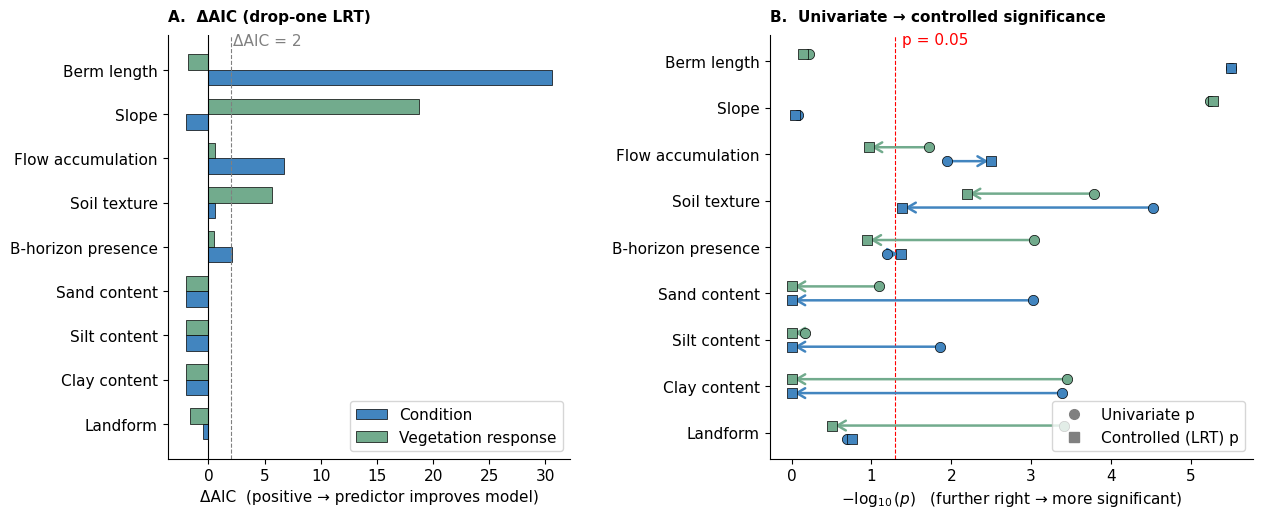

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Outcome colours (match model figures) ─────────────────────────────────
from constants import MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, FS

_CLR_C = MODEL_CLR_CONDITION   # blue
_CLR_V = MODEL_CLR_VEGRESPONSE # sage
_FS    = FS                    # uniform font size for this figure

# ── Build combined DataFrame ──────────────────────────────────────────────
_pred_order = ['Berm length', 'Slope', 'Landform', 'Soil texture',
               'B-horizon presence', 'Flow accumulation', 'Clay content',
               'Silt content', 'Sand content']
_viz = pd.DataFrame({'Predictor': _pred_order})
_viz = _viz.merge(
    _cond_summary[['Predictor', 'Univariate p', 'LRT p', '\u0394AIC']].rename(
        columns={'Univariate p': 'Uni_p_cond', 'LRT p': 'LRT_p_cond', '\u0394AIC': 'dAIC_cond'}),
    on='Predictor')
_viz = _viz.merge(
    _eff_summary[['Predictor', 'Univariate p', 'LRT p', '\u0394AIC']].rename(
        columns={'Univariate p': 'Uni_p_eff', 'LRT p': 'LRT_p_eff', '\u0394AIC': 'dAIC_eff'}),
    on='Predictor')

# Sort by max |ΔAIC| ascending so biggest bars are at top
_viz['_sort'] = _viz[['dAIC_cond', 'dAIC_eff']].abs().max(axis=1)
_viz = _viz.sort_values('_sort', ascending=True).reset_index(drop=True)
_n  = len(_viz)
_y  = np.arange(_n)
_bw = 0.35

# ─────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.45)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Panel A: ΔAIC grouped horizontal bars ─────────────────────────────────
ax1.barh(_y - _bw/2, _viz['dAIC_cond'], _bw, label='Condition',
         color=_CLR_C, edgecolor='black', linewidth=0.5)
ax1.barh(_y + _bw/2, _viz['dAIC_eff'], _bw, label='Vegetation response',
         color=_CLR_V, edgecolor='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.axvline(2, color='grey', linewidth=0.8, linestyle='--')
ax1.text(2.2, _n - 0.5, '\u0394AIC = 2', fontsize=_FS, color='grey', va='bottom')
ax1.set_yticks(_y)
ax1.set_yticklabels(_viz['Predictor'], fontsize=_FS)
ax1.set_xlabel('\u0394AIC  (positive \u2192 predictor improves model)', fontsize=_FS)
ax1.set_title('A.  \u0394AIC (drop-one LRT)', fontsize=_FS, fontweight='bold', loc='left', pad=10)
ax1.legend(fontsize=_FS, loc='lower right')
ax1.tick_params(labelsize=_FS)
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel B: univariate → controlled significance shift ───────────────────
_cap = 5.5  # cap -log10(p) for display
def _nl(p):
    return min(-np.log10(max(p, 1e-10)), _cap)

_thresh = -np.log10(0.05)  # ≈ 1.30

_min_gap = 0.15  # suppress arrow when markers are closer than this

for i, row in _viz.iterrows():
    # Condition (offset down)
    _uc = _nl(row['Uni_p_cond']); _lc = _nl(row['LRT_p_cond'])
    if abs(_lc - _uc) >= _min_gap:
        ax2.annotate('', xy=(_lc, i - 0.15), xytext=(_uc, i - 0.15),
                     arrowprops=dict(arrowstyle='->,head_length=0.6,head_width=0.35', color=_CLR_C, lw=1.8))
    ax2.scatter(_uc, i - 0.15, marker='o', s=55, color=_CLR_C,
                edgecolors='black', linewidth=0.5, zorder=3)
    ax2.scatter(_lc, i - 0.15, marker='s', s=55, color=_CLR_C,
                edgecolors='black', linewidth=0.5, zorder=3)
    # Vegetation response (offset up)
    _ue = _nl(row['Uni_p_eff']); _le = _nl(row['LRT_p_eff'])
    if abs(_le - _ue) >= _min_gap:
        ax2.annotate('', xy=(_le, i + 0.15), xytext=(_ue, i + 0.15),
                     arrowprops=dict(arrowstyle='->,head_length=0.6,head_width=0.35', color=_CLR_V, lw=1.8))
    ax2.scatter(_ue, i + 0.15, marker='o', s=55, color=_CLR_V,
                edgecolors='black', linewidth=0.5, zorder=3)
    ax2.scatter(_le, i + 0.15, marker='s', s=55, color=_CLR_V,
                edgecolors='black', linewidth=0.5, zorder=3)

ax2.axvline(_thresh, color='red', linewidth=0.8, linestyle='--')
ax2.text(_thresh + 0.08, _n - 0.7, 'p = 0.05', fontsize=_FS, color='red', va='bottom')
ax2.set_yticks(_y)
ax2.set_yticklabels(_viz['Predictor'], fontsize=_FS)
ax2.set_xlabel('$-\\log_{10}(p)$   (further right \u2192 more significant)', fontsize=_FS)
ax2.set_title('B.  Univariate \u2192 controlled significance', fontsize=_FS, fontweight='bold', loc='left', pad=10)
ax2.tick_params(labelsize=_FS)
ax2.spines[['top', 'right']].set_visible(False)

_handles = [
    Line2D([0], [0], marker='o', color='grey', markerfacecolor='grey',
           markersize=7, linestyle='None', label='Univariate p'),
    Line2D([0], [0], marker='s', color='grey', markerfacecolor='grey',
           markersize=7, linestyle='None', label='Controlled (LRT) p'),
]
ax2.legend(handles=_handles, fontsize=_FS, loc='lower right')

plt.tight_layout()
plt.show()

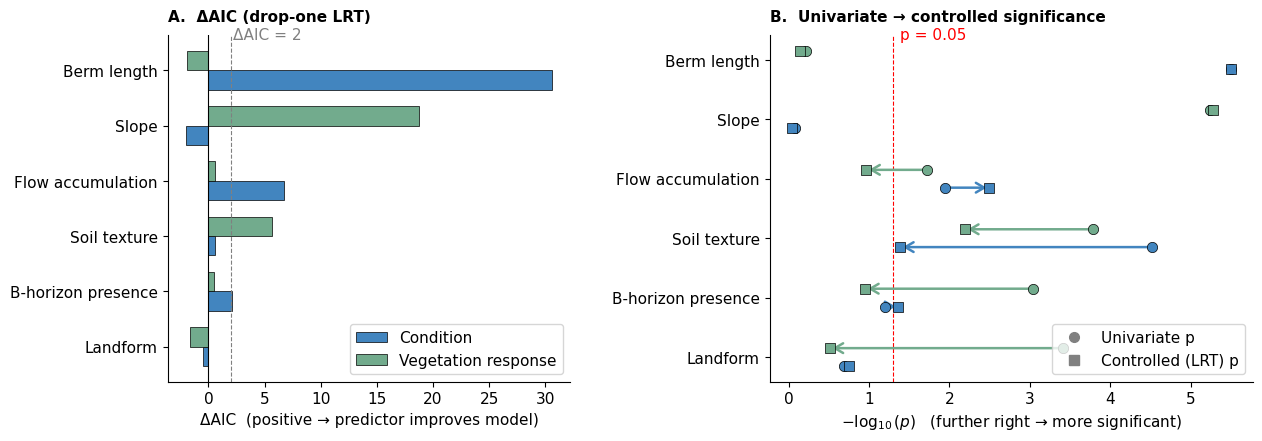

In [8]:
import pandas as pd
# ── Version without particle-size fractions ────────────────────────────────
_pred_order_6 = ['Berm length', 'Slope', 'Landform', 'Soil texture',
                 'B-horizon presence', 'Flow accumulation']
_viz6 = pd.DataFrame({'Predictor': _pred_order_6})
_viz6 = _viz6.merge(
    _cond_summary[['Predictor', 'Univariate p', 'LRT p', '\u0394AIC']].rename(
        columns={'Univariate p': 'Uni_p_cond', 'LRT p': 'LRT_p_cond', '\u0394AIC': 'dAIC_cond'}),
    on='Predictor')
_viz6 = _viz6.merge(
    _eff_summary[['Predictor', 'Univariate p', 'LRT p', '\u0394AIC']].rename(
        columns={'Univariate p': 'Uni_p_eff', 'LRT p': 'LRT_p_eff', '\u0394AIC': 'dAIC_eff'}),
    on='Predictor')

_viz6['_sort'] = _viz6[['dAIC_cond', 'dAIC_eff']].abs().max(axis=1)
_viz6 = _viz6.sort_values('_sort', ascending=True).reset_index(drop=True)
_n6 = len(_viz6)
_y6 = np.arange(_n6)

fig = plt.figure(figsize=(14, 4.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.45)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Panel A: ΔAIC grouped horizontal bars ─────────────────────────────────
ax1.barh(_y6 - _bw/2, _viz6['dAIC_cond'], _bw, label='Condition',
         color=_CLR_C, edgecolor='black', linewidth=0.5)
ax1.barh(_y6 + _bw/2, _viz6['dAIC_eff'], _bw, label='Vegetation response',
         color=_CLR_V, edgecolor='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.axvline(2, color='grey', linewidth=0.8, linestyle='--')
ax1.text(2.2, _n6 - 0.5, '\u0394AIC = 2', fontsize=_FS, color='grey', va='bottom')
ax1.set_yticks(_y6)
ax1.set_yticklabels(_viz6['Predictor'], fontsize=_FS)
ax1.set_xlabel('\u0394AIC  (positive \u2192 predictor improves model)', fontsize=_FS)
ax1.set_title('A.  \u0394AIC (drop-one LRT)', fontsize=_FS, fontweight='bold', loc='left', pad=10)
ax1.legend(fontsize=_FS, loc='lower right')
ax1.tick_params(labelsize=_FS)
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel B: univariate → controlled significance shift ───────────────────
for i, row in _viz6.iterrows():
    _uc = _nl(row['Uni_p_cond']); _lc = _nl(row['LRT_p_cond'])
    if abs(_lc - _uc) >= _min_gap:
        ax2.annotate('', xy=(_lc, i - 0.15), xytext=(_uc, i - 0.15),
                     arrowprops=dict(arrowstyle='->,head_length=0.6,head_width=0.35', color=_CLR_C, lw=1.8))
    ax2.scatter(_uc, i - 0.15, marker='o', s=55, color=_CLR_C,
                edgecolors='black', linewidth=0.5, zorder=3)
    ax2.scatter(_lc, i - 0.15, marker='s', s=55, color=_CLR_C,
                edgecolors='black', linewidth=0.5, zorder=3)
    _ue = _nl(row['Uni_p_eff']); _le = _nl(row['LRT_p_eff'])
    if abs(_le - _ue) >= _min_gap:
        ax2.annotate('', xy=(_le, i + 0.15), xytext=(_ue, i + 0.15),
                     arrowprops=dict(arrowstyle='->,head_length=0.6,head_width=0.35', color=_CLR_V, lw=1.8))
    ax2.scatter(_ue, i + 0.15, marker='o', s=55, color=_CLR_V,
                edgecolors='black', linewidth=0.5, zorder=3)
    ax2.scatter(_le, i + 0.15, marker='s', s=55, color=_CLR_V,
                edgecolors='black', linewidth=0.5, zorder=3)

ax2.axvline(_thresh, color='red', linewidth=0.8, linestyle='--')
ax2.text(_thresh + 0.08, _n6 - 0.7, 'p = 0.05', fontsize=_FS, color='red', va='bottom')
ax2.set_yticks(_y6)
ax2.set_yticklabels(_viz6['Predictor'], fontsize=_FS)
ax2.set_xlabel('$-\\log_{10}(p)$   (further right \u2192 more significant)', fontsize=_FS)
ax2.set_title('B.  Univariate \u2192 controlled significance', fontsize=_FS, fontweight='bold', loc='left', pad=10)
ax2.tick_params(labelsize=_FS)
ax2.spines[['top', 'right']].set_visible(False)

_handles = [
    Line2D([0], [0], marker='o', color='grey', markerfacecolor='grey',
           markersize=7, linestyle='None', label='Univariate p'),
    Line2D([0], [0], marker='s', color='grey', markerfacecolor='grey',
           markersize=7, linestyle='None', label='Controlled (LRT) p'),
]
ax2.legend(handles=_handles, fontsize=_FS, loc='lower right')

plt.tight_layout()
plt.show()

In [9]:
from pathlib import Path
from registry import register_outcomes_figure

_fig3_name = 'fig3_controlled_predictors.png'
_fig3_out = Path(f'../figures/outcomes/{_fig3_name}')
_fig3_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig3_out, dpi=300, bbox_inches='tight')
print(f'Saved: {_fig3_name}')

register_outcomes_figure(
    'FIG_3',
    label='fig3',
    file_name=_fig3_name,
    stats_text=(
        'Side-by-side comparison of univariate and controlled (LRT) predictor significance '
        'for berm structural condition and vegetation response. '
        'Panel A: ΔAIC from drop-one likelihood ratio tests (positive = predictor improves model). '
        'Panel B: shift from univariate to controlled p-values (circles = univariate, '
        'squares = controlled). Six predictors: berm length, slope, landform, '
        'soil texture, B-horizon presence, flow accumulation.'
    ),
    interpretation_text=(
        'Flow accumulation and berm length are the strongest controlled predictors of condition '
        '(largest ΔAIC), while slope drives vegetation response. '
        'Several predictors that are significant in univariate tests (e.g. landform, soil texture) '
        'lose significance after controlling for confounders, indicating that their apparent effects '
        'are partly mediated by correlated site characteristics.'
    ),
)


Saved: fig3_controlled_predictors.png
Updated → ../latex/figure_report_outcomes.tex  (fig3)


**Figure — Independent predictor contributions to berm condition and vegetation response.**
**(A)** ΔAIC from drop-one likelihood-ratio tests. Positive values indicate that removing the focal predictor worsens model fit; the dotted line marks the conventional ΔAIC = 2 threshold. Positive bars exceeding the ΔAIC = 2 threshold indicate predictors whose removal meaningfully worsens model fit. The three particle-size fractions (clay, silt, sand) test whether each component contributes beyond the other eight predictors, including the other two fractions. Interpret their individual ΔAIC values cautiously given compositional multicollinearity.
**(B)** Shift in significance from univariate tests (circles) to controlled likelihood-ratio tests (squares). Arrows connect the two; the red dashed line marks p = 0.05. Key patterns: landform's vegetation-response signal collapses after controlling (strong leftward shift past the significance line), revealing complete confounding with slope and texture. B-horizon presence shows the opposite — a suppression effect for condition, gaining significance only after controlling. Predictors whose markers stay to the right of the significance line in both frameworks are direct, non-confounded predictors. Shifts leftward past the line reveal confounding; shifts rightward reveal suppression. The particle-size fractions may show collinearity-driven attenuation of controlled significance.

In [10]:
def _sig(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

_comp = _cond_summary[['Predictor']].copy()
_comp['Condition: Uni p']   = _cond_summary['Univariate p'].apply(lambda p: f"{p:.4f} ({_sig(p)})")
_comp['Condition: LRT p']   = _cond_summary['LRT p'].apply(lambda p: f"{p:.4f} ({_sig(p)})")
_comp['Condition: \u0394AIC']   = _cond_summary['\u0394AIC'].apply(lambda v: f"{v:+.1f}")
_comp['Effective: Uni p']   = _eff_summary['Univariate p'].apply(lambda p: f"{p:.4f} ({_sig(p)})")
_comp['Effective: LRT p']   = _eff_summary['LRT p'].apply(lambda p: f"{p:.4f} ({_sig(p)})")
_comp['Effective: \u0394AIC']   = _eff_summary['\u0394AIC'].apply(lambda v: f"{v:+.1f}")

print("Side-by-side: univariate vs controlled significance for each predictor")
print("Positive \u0394AIC = dropping the focal predictor worsens the model\n")
display(_comp.style.hide(axis='index'))


Side-by-side: univariate vs controlled significance for each predictor
Positive ΔAIC = dropping the focal predictor worsens the model



Predictor,Condition: Uni p,Condition: LRT p,Condition: ΔAIC,Effective: Uni p,Effective: LRT p,Effective: ΔAIC
Berm length,0.0000 (***),0.0000 (***),+30.6,0.6091 (ns),0.7116 (ns),-1.9
Slope,0.8249 (ns),0.9187 (ns),-2.0,0.0000 (***),0.0000 (***),+18.8
Landform,0.2035 (ns),0.1754 (ns),-0.5,0.0004 (***),0.3097 (ns),-1.7
Soil texture,0.0000 (***),0.0412 (*),+0.6,0.0002 (***),0.0064 (**),+5.6
B-horizon presence,0.0633 (ns),0.0430 (*),+2.1,0.0009 (***),0.1122 (ns),+0.5
Flow accumulation,0.0112 (*),0.0032 (**),+6.7,0.0192 (*),0.1084 (ns),+0.6
Clay content,0.0004 (***),1.0000 (ns),-2.0,0.0004 (***),1.0000 (ns),-2.0
Silt content,0.0137 (*),1.0000 (ns),-2.0,0.6863 (ns),1.0000 (ns),-2.0
Sand content,0.0009 (***),1.0000 (ns),-2.0,0.0793 (ns),1.0000 (ns),-2.0


In [11]:
from pathlib import Path

_out = Path('../data/summary')
_out.mkdir(parents=True, exist_ok=True)

_cond_summary.to_csv(_out / 'controlled_predictors_condition.csv', index=False)
_eff_summary.to_csv(_out / 'controlled_predictors_vegetation.csv', index=False)
_comp.to_csv(_out / 'controlled_predictors_comparison.csv', index=False)

print(f"Saved 3 CSV files to {_out}/")


Saved 3 CSV files to ../data/summary/


## Cross-outcome synthesis

### Different predictors dominate each outcome

> **Note:** The specific ΔAIC values below were computed under a previous 6-predictor model. The model now includes nine predictors (adding clay, silt, and sand content). Verify the values against the current cell output and add interpretations for the three particle-size fractions. Because clay + silt + sand sum to ~100 %, their individual LRTs test marginal contributions given compositional collinearity.

The two outcomes — structural condition and vegetation response — are governed by **largely non-overlapping** sets of independent predictors:

|  | Condition (intact) | Vegetation response |
|---|---|---|
| **Strong independent predictors** | Berm length (ΔAIC +30.6), flow accumulation (+6.7) | Slope (ΔAIC +18.9) |
| **Moderate independent predictors** | Soil texture (+3.0), B-horizon (+2.3) | Soil texture (+4.3) |
| **Confounded / non-significant** | Slope, landform | Landform, B-horizon, flow accumulation, berm length |

Soil texture is the only predictor that contributes independently to *both* outcomes, though its effect is modest in both cases.

### Confounding patterns

Three important confounding patterns emerge:

1. **Landform is a proxy, not a cause.** Despite strong univariate associations with vegetation response (p < 0.001), landform adds nothing to the controlled model (LRT p = 0.42). Its apparent effect is entirely explained by the slope and texture gradients that distinguish fan terraces, stream terraces, and flood plains.

2. **B-horizon presence is suppressed for condition.** The univariate test (p = 0.063) understates its true effect. After controlling for confounders the B-horizon effect on condition strengthens to p = 0.038. Correlated variables (e.g., landform, texture) mask the independent soil-development signal.

3. **Slope matters for vegetation but not condition; length matters for condition but not vegetation.** These two outcomes respond to fundamentally different site characteristics. Structural integrity is a function of design (length) and hydraulic loading (flow accumulation). Vegetation response is a function of the terrain's ability to concentrate and deliver water (slope) and the soil's capacity to support plant growth (texture).

### Practical implications

- **For predicting structural failure risk:** prioritise berm length, upstream contributing area, and soil texture information.
- **For predicting vegetation benefit:** prioritise slope and soil texture. Landform is a useful field shorthand but adds no information beyond what slope and texture already provide.
- **B-horizon presence** provides a modest but real signal for structural condition that is not captured by the other variables. This may reflect the influence of subsurface soil structure on berm foundation stability.

### Model limitations

- Both models have low pseudo R² (0.05–0.08), indicating that the predictors examined here explain only a small fraction of outcome variance. Unmeasured factors (berm construction quality, local hydrology, maintenance history, age) likely play a large role.
- RF CV AUC values (0.67–0.74) suggest moderate but imperfect discriminative ability.
- All predictors enter the model linearly (or as dummy variables); non-linear or interaction effects are not captured by the logistic framework, though the random forest provides a partial check.

Controlled OR (95 % CI) is the odds ratio for a focal predictor extracted from the full logistic regression (the one with all nine predictors in it simultaneously). Because every other predictor is held constant in that model, this OR reflects the independent effect — how much a one-unit increase in the focal variable changes the odds of the outcome, net of confounders.

The Wald p-value is the default significance test that logistic regression software reports next to each coefficient. 
In a logistic regression, each predictor gets a coefficient (β) and a standard error (SE) for that coefficient. The Wald statistic is  the ratio: **z = β / SE**. This follows the same intuition as a t-test — quantifying how many standard errors the coefficient is from zero. If β is large relative to its uncertainty, the ratio is large, and the predictor is likely contributing something real. We then compare z² to a chi-square distribution with 1 degree of freedom (or equivalently, compare z to a standard normal) to get the p-value.
